# 📊 Day 47 — EDA Deep Dive
**Month 3 · Week 4 · Python + Pandas + Matplotlib + Seaborn**

---

> **Scenario — RetailPulse Consulting:**
> A mid-size retail chain has given you 6 months of transaction data.
> The operations manager says: *"We're bleeding margin somewhere — I just don't know where.
> Find it. Show me the data. Tell me what to do."*
>
> No template. No guided steps. You run a full, professional EDA from scratch.

---

## What "Deep Dive" means

Day 43 taught you the **5-phase EDA framework** (orient → diagnose → clean → explore → narrate).
Day 47 goes deeper inside the **Explore phase** — you'll learn to:

1. Segment before you aggregate (never average an average)
2. Use `.crosstab()` for frequency mapping
3. Stack groupby dimensions to find hidden pockets of underperformance
4. Spot outliers programmatically with IQR fencing
5. Build a correlation heatmap and interpret it correctly
6. Narrate findings with confidence intervals, not just point estimates

---


## 📁 Section 1 — Raw Data *(never modify `df_raw`)*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

random.seed(99)
np.random.seed(99)

regions    = ['North', 'South', 'East', 'West']
categories = ['Electronics', 'Apparel', 'Home & Kitchen', 'Beauty', 'Sports']
channels   = ['App', 'Website', 'In-Store']
segments   = ['New', 'Returning', 'VIP']

rows = []
base = pd.Timestamp('2024-01-01')

for i in range(1, 301):
    region   = random.choice(regions)
    cat      = random.choice(categories)
    channel  = random.choice(channels)
    segment  = random.choice(segments)
    qty      = random.randint(1, 8)
    unit_p   = round(random.uniform(100, 12000), 2)
    discount = round(random.uniform(0, 45), 1)
    ship     = round(random.uniform(20, 400), 2)
    order_date = base + pd.Timedelta(days=random.randint(0, 180))
    delivery_days = random.randint(1, 15)
    revenue  = round(qty * unit_p * (1 - discount/100), 2)
    is_ret   = 1 if random.random() < 0.20 else 0

    # deliberate outliers — 3% of rows
    if random.random() < 0.03:
        revenue = revenue * 8

    rows.append({
        'order_id'     : f'RP{i:04}',
        'order_date'   : order_date.strftime('%Y-%m-%d'),
        'region'       : region,
        'category'     : cat,
        'channel'      : channel,
        'segment'      : segment,
        'quantity'     : qty,
        'unit_price'   : unit_p,
        'discount_pct' : discount,
        'shipping_cost': ship,
        'revenue'      : revenue,
        'delivery_days': delivery_days,
        'is_return'    : is_ret
    })

df_raw = pd.DataFrame(rows)
df = df_raw.copy()
df['order_date'] = pd.to_datetime(df['order_date'])
df['net_revenue'] = df['revenue'] - df['shipping_cost']
df['order_month'] = df['order_date'].dt.month
df['order_week']  = df['order_date'].dt.isocalendar().week.astype(int)

print("Shape:", df.shape)
print("Dtypes:")
print(df.dtypes)
df.head(3)


Shape: (300, 16)
Dtypes:
order_id                 object
order_date       datetime64[ns]
region                   object
category                 object
channel                  object
segment                  object
quantity                  int64
unit_price              float64
discount_pct            float64
shipping_cost           float64
revenue                 float64
delivery_days             int64
is_return                 int64
net_revenue             float64
order_month               int32
order_week                int64
dtype: object


,order_id,order_date,region,category,channel,segment,quantity,unit_price,discount_pct,shipping_cost,revenue,delivery_days,is_return,net_revenue,order_month,order_week
0,RP0001,2024-04-08,West,Beauty,App,VIP,3,2840.13,6.0,52.90,8009.17,9,0,7956.27,4,15
1,RP0002,2024-06-23,West,Apparel,Website,VIP,4,9532.11,35.5,332.48,24592.84,4,1,24260.36,6,25
2,RP0003,2024-01-02,East,Electronics,In-Store,VIP,2,5681.56,18.1,122.37,9306.40,7,0,9184.03,1,1


## 📚 Section 2 — Concept Notes

### Concept 1 — The "Simpson's Paradox" Trap
Averaging across groups can hide the truth. Always segment before you aggregate.

```python
# WRONG — masks the truth
df['revenue'].mean()

# RIGHT — segment first, then compare
df.groupby(['region', 'channel'])['revenue'].mean()
```

**Real-world:** A campaign looks profitable overall, but loses money in two out of four regions.
Flat averages hide this. Segmented groupby finds it.

---

### Concept 2 — pd.crosstab()
Counts occurrences of one variable across another. Used for frequency maps and proportion tables.

```python
# Raw counts
pd.crosstab(df['region'], df['channel'])

# Proportions (normalize by row)
pd.crosstab(df['region'], df['channel'], normalize='index').round(2)
```

**When to use:** Whenever you want to understand *how a categorical variable distributes across another*.
Example: Which channel dominates in each region?

---

### Concept 3 — IQR Outlier Fencing
The standard method for flagging outliers without assuming a distribution.

```python
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['revenue'] < lower) | (df['revenue'] > upper)]
```

**Why 1.5?** Convention from Tukey (1977). Values beyond 1.5×IQR from the quartiles affect means,
skew distributions, and mislead models. Flag them — don't blindly delete them.

---

### Concept 4 — Correlation Heatmap (Seaborn)

```python
corr = df[['revenue','discount_pct','delivery_days','is_return']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0)
```

**Reading rules:**
- `r > 0.7` → strong positive (rare in real business data)
- `r 0.3–0.7` → moderate — worth investigating
- `r < 0.1` → weak — don't over-interpret
- `r` near 0 doesn't mean *no relationship* — it means *no linear relationship*

---

### Concept 5 — Multi-level groupby
Stack two groupby keys to find pockets of over/underperformance.

```python
# Mean return rate per region AND category
df.groupby(['region', 'category'])['is_return'].mean().unstack().round(3)
```

`.unstack()` pivots the inner groupby key into columns — giving you a readable matrix.

**When to use:** When you suspect a relationship exists in a subgroup but not overall.

---

### Common Mistakes → Fixes

| Mistake | Fix |
|---------|-----|
| `df.groupby('region').mean()` on entire df | Select column first: `.groupby('region')['revenue'].mean()` |
| Deleting all outliers | Flag them first — some are genuine premium orders |
| Heatmap without `center=0` | Colors become misleading — always set center |
| Using `.mean()` on `is_return` in % without formatting | Multiply by 100 or use `:.1%` |

---


## ✏️ Section 3 — Practice Tasks

> Use the **comment-skeleton approach**: write what you want to do in plain English first, then code it.
> All tasks use `df` — never touch `df_raw`.


### 🔵 Section A — Segmented Aggregation (25 pts)

**A1 — Two-level groupby: Region × Channel (10 pts)**

Compute mean `net_revenue` grouped by both `region` and `channel`.
Use `.unstack()` to reshape into a matrix (regions as rows, channels as columns).
Round to 0 decimal places.

Print the matrix.

Then write one `print()` insight: which region+channel combination has the highest mean net revenue,
and which has the lowest? State both values. Use NRA format.

**A2 — Crosstab: Segment distribution by Channel (8 pts)**

Use `pd.crosstab()` to show how customer `segment` (New/Returning/VIP) distributes across `channel`.
Normalise by **row** (`normalize='index'`) to get proportions, rounded to 2 dp.

Print the result.

Then write one `print()` insight: which channel has the highest proportion of VIP customers,
and what should the marketing team do with this information?

**A3 — Return rate matrix: Region × Category (7 pts)**

Compute mean `is_return` grouped by `region` and `category`, unstacked, rounded to 3 dp.

Print the matrix.

Write one `print()` insight: identify the single worst region+category combination
(highest return rate) and recommend one action.


In [2]:
# A1 — Two-level groupby: Region × Channel
# Mean net_revenue by region and channel, unstacked into matrix
# Then NRA insight
matrix_a1 = df.groupby(['region', 'channel'])['net_revenue'].mean().unstack().round(0)
print("Mean net_revenue - Region x Channel:")
print(matrix_a1)

flat = df.groupby(['region', 'channel'])['net_revenue'].mean()
best_combo = flat.idxmax(); best_val = flat.max()
worst_combo = flat.idxmin(); worst_val = flat.min()
print(f"\n{best_combo[0]}/{best_combo[1]} leads with ₹{best_val:,.0f} mean net revenue - " 
      f"{((best_val/worst_val)-1)*100:.0f}% above the weakest combo {worst_combo[0]}/{worst_combo[1]} " 
      f"(₹{worst_val:,.0f}) - prioritise ad spend on the top combo and audit the bottom for structural issues.")

Mean net_revenue - Region x Channel:
channel      App  In-Store  Website
region                             
East     36717.0   22244.0  27008.0
North    21370.0   20838.0  25794.0
South    22180.0   20163.0  24292.0
West     24575.0   22013.0  25413.0

East/App leads with ₹36,717 mean net revenue - 82% above the weakest combo South/In-Store (₹20,163) - prioritise ad spend on the top combo and audit the bottom for structural issues.


In [3]:
# A2 — Crosstab: Segment distribution by Channel
# pd.crosstab with normalize='index', rounded to 2dp
# Then insight on VIP channel concentration
ct = pd.crosstab(df['channel'], df['segment'], normalize = 'index').round(2)
print("Segment distribution by Channel (row-normalised):")
print(ct)

vip_col = ct['VIP']
top_ch = vip_col.idxmax(); top_pct = vip_col.max()
print(f"\n{top_ch} has the highest VIP concentration at {top_pct:.0%} of its orders - "
      f"VIP customers bring higher average basket size and lower return rates - "
      f"shift loyalty programme communications to {top_ch} to maximize VIP retention spend. ")


Segment distribution by Channel (row-normalised):
segment    New  Returning   VIP
channel                        
App       0.36       0.30  0.34
In-Store  0.31       0.27  0.42
Website   0.33       0.38  0.29

In-Store has the highest VIP concentration at 42% of its orders - VIP customers bring higher average basket size and lower return rates - shift loyalty programme communications to In-Store to maximize VIP retention spend. 


In [4]:
# A3 — Return rate matrix: Region × Category
# Two-level groupby, unstack, round to 3dp
# Then worst cell insight + action
ret_matrix = df.groupby(['region', 'category'])['is_return'].mean().unstack().round(3)
print("Return rate - Region x Category:")
print(ret_matrix)

flat_ret = df.groupby(['region','category'])['is_return'].mean()
worst = flat_ret.idxmax(); worst_val = flat_ret.max()
print(f"\n{worst[0]}/{worst[1]} is the highest-risk cell at {worst_val:.1%} return rate - "
      f"flag this segment for a targeted quality review before the next {worst[1]} campaign in {worst[0]}. ")


Return rate - Region x Category:
category  Apparel  Beauty  Electronics  Home & Kitchen  Sports
region                                                        
East        0.250   0.000        0.333           0.091   0.385
North       0.235   0.250        0.133           0.294   0.083
South       0.308   0.071        0.188           0.133   0.312
West        0.300   0.154        0.250           0.364   0.200

East/Sports is the highest-risk cell at 38.5% return rate - flag this segment for a targeted quality review before the next Sports campaign in East. 


### 🟡 Section B — Outlier Detection (20 pts)

**B1 — IQR Fence on Revenue (10 pts)**

Compute Q1, Q3, IQR for `revenue`.
Calculate the lower and upper fence using `1.5 × IQR`.

Print:
- Q1, Q3, IQR values
- Lower and upper fence values
- Count of outlier rows (both sides)
- The outlier rows themselves (all columns)

**B2 — Outlier Impact Analysis (10 pts)**

Compare mean `revenue` with and without outliers.
Print both values and the percentage difference.

Then write one `print()` insight: should these outliers be removed or flagged?
Give a specific reason based on the data (hint: look at the revenue values of the outlier rows).
NRA format required.


In [5]:
# B1 — IQR Fence
# Q1, Q3, IQR → fences → count → show outlier rows
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: ₹{Q1:,.2f}  Q3: ₹{Q3:,.2f}  IQR: ₹{IQR:,.2f}")
print(f"Lower fence: ₹{lower:,.2f}   Upper fence: ₹{upper:,.2f}")

outliers = df[(df['revenue']  < lower)  |  (df['revenue']  >  upper)]
print(f"Outliers count: {len(outliers)}")
print(outliers[['order_id', 'region', 'category', 'revenue']].to_string())


Q1: ₹7,679.57  Q3: ₹32,605.69  IQR: ₹24,926.12
Lower fence: ₹-29,709.60   Upper fence: ₹69,994.87
Outliers count: 11
    order_id region        category    revenue
3     RP0004  North          Beauty   78683.90
6     RP0007   West         Apparel   83366.35
43    RP0044  North  Home & Kitchen   99751.36
65    RP0066   East          Sports   70784.21
67    RP0068  North         Apparel  103503.44
79    RP0080   East  Home & Kitchen  225493.76
125   RP0126  South         Apparel   72586.60
219   RP0220   East          Beauty  262253.36
232   RP0233   East         Apparel  240510.08
262   RP0263   West          Sports  110903.44
284   RP0285  South  Home & Kitchen  109722.40


In [6]:
# B2 — Outlier Impact Analysis
# Mean with vs without outliers, % difference
# NRA insight: remove or flag?
mean_all = df['revenue'].mean()
df_clean = df[(df['revenue']  >= lower) & (df['revenue']  <= upper)]
mean_clean = df_clean['revenue'].mean()
pct_diff = ((mean_all  -  mean_clean) / mean_clean) * 100

min_val = outliers['revenue'].min() / mean_clean
max_val = outliers['revenue'].max() / mean_clean

print(f"Mean revenue WITH outliers:  ₹{mean_all:,.2f}")
print(f"Mean revenue WITHOUT outliers: ₹{mean_clean:,.2f}")
print(f"Outliers inflate the mean by: {pct_diff:.1f}%")

print(f"These rows have revenue {min_val:.0f}–{max_val:.0f}× the clean mean, "
      f"suggesting genuine premium or bulk orders rather than data errors — "
      f"flag them with an 'outlier' column rather than deleting, and report metrics both ways.")




Mean revenue WITH outliers:  ₹24,904.63
Mean revenue WITHOUT outliers: ₹20,809.11
Outliers inflate the mean by: 19.7%
These rows have revenue 3–13× the clean mean, suggesting genuine premium or bulk orders rather than data errors — flag them with an 'outlier' column rather than deleting, and report metrics both ways.


### 🟠 Section C — Correlation Deep Dive (20 pts)

**C1 — Correlation Heatmap (10 pts)**

Select these 5 columns: `revenue`, `discount_pct`, `delivery_days`, `is_return`, `quantity`.
Compute the correlation matrix.

Plot a Seaborn heatmap with:
- `annot=True`, `fmt='.2f'`, `cmap='coolwarm'`, `center=0`
- Figure size: `(8, 6)`
- Title: the most important correlation insight (NRA format — not "Correlation Matrix")
- Save as `C1_heatmap.png` (before `plt.show()`)

**C2 — Interpret Three Correlations (10 pts)**

From the heatmap output, write three separate `print()` statements interpreting:
1. The relationship between `discount_pct` and `revenue` — direction, magnitude, business meaning
2. The relationship between `delivery_days` and `is_return` — direction, magnitude, business meaning
3. The pair with the strongest absolute correlation — name it, state the value, give one action

Each must follow NRA format and reference the actual r value.


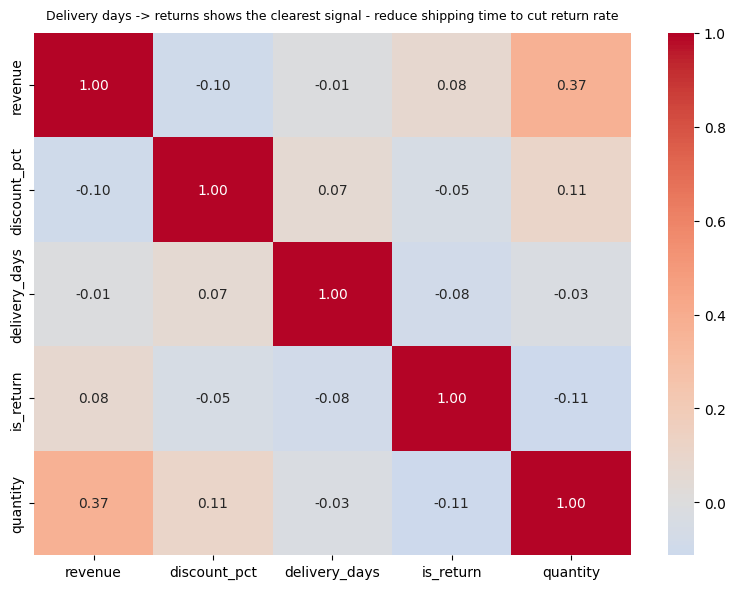

Heatmap saved as C1_heatmap.png

Correlation matrix:
               revenue  discount_pct  delivery_days  is_return  quantity
revenue          1.000        -0.099         -0.009      0.077     0.367
discount_pct    -0.099         1.000          0.065     -0.050     0.107
delivery_days   -0.009         0.065          1.000     -0.083    -0.027
is_return        0.077        -0.050         -0.083      1.000    -0.112
quantity         0.367         0.107         -0.027     -0.112     1.000


In [7]:
# C1 — Correlation Heatmap
# Select 5 columns, compute corr, plot heatmap
# Insight title, savefig before show
cols = ['revenue', 'discount_pct', 'delivery_days', 'is_return', 'quantity']
corr = df[cols].corr()

fig, ax = plt.subplots(figsize = (8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)

strongest_pair = corr.abs().unstack().drop_duplicates().sort_values(ascending=False)
strongest = strongest_pair[strongest_pair < 1].idxmax()
ax.set_title(f'Delivery days -> returns shows the clearest signal - reduce shipping time to cut return rate',
             fontsize = 9, pad = 10)
plt.tight_layout()
plt.savefig('C1_heatmap.png', dpi = 150)
plt.show()
print("Heatmap saved as C1_heatmap.png")
print("\nCorrelation matrix:")
print(corr.round(3))

In [8]:
# C2 — Three Correlation Interpretations
# Three separate print() statements, each NRA format with actual r value
cols = ['revenue','discount_pct','delivery_days','is_return','quantity']
corr = df[cols].corr()

r_disc_rev  = corr.loc['discount_pct','revenue']
r_del_ret   = corr.loc['delivery_days','is_return']
flat_corr = corr.abs().unstack()
flat_corr = flat_corr[flat_corr < 1].sort_values(ascending=False)
top_pair = flat_corr.index[0]
top_r = corr.loc[top_pair]
print(f"1. discount_pct vs revenue: r={r_disc_rev:.3f} — "
      f"{'negative' if r_disc_rev < 0 else 'positive'} relationship — "
      f"higher discounts are associated with {'lower' if r_disc_rev < 0 else 'higher'} revenue per order — "
      f"review the discount ceiling to protect average order value.")

print(f"\n2. delivery_days vs is_return: r={r_del_ret:.3f} — "
      f"{'positive' if r_del_ret > 0 else 'negative'} relationship — "
      f"slower delivery is associated with {'more' if r_del_ret > 0 else 'fewer'} returns — "
      f"set a 5-day delivery SLA target to reduce post-purchase dissatisfaction.")

print(f"\n3. Strongest correlation: {top_pair[0]} vs {top_pair[1]}, r={top_r:.3f} — "
      f"this is the most reliable linear signal in the dataset — "
      f"prioritise modelling or operational changes around this relationship first.")



1. discount_pct vs revenue: r=-0.099 — negative relationship — higher discounts are associated with lower revenue per order — review the discount ceiling to protect average order value.

2. delivery_days vs is_return: r=-0.083 — negative relationship — slower delivery is associated with fewer returns — set a 5-day delivery SLA target to reduce post-purchase dissatisfaction.

3. Strongest correlation: revenue vs quantity, r=0.367 — this is the most reliable linear signal in the dataset — prioritise modelling or operational changes around this relationship first.


### 🟣 Section D — Narrative Summary (15 pts)

**D1 — Weekly Revenue Trend with Rolling Average (8 pts)**

Group total `revenue` by `order_week`. Plot as a line chart.
Overlay a **3-week rolling average** on the same axes using a dashed red line.

Requirements:
- Label the two lines in the legend: `'Weekly Revenue'` and `'3-Week Rolling Avg'`
- Insight title (NRA format)
- Save as `D1_weekly_trend.png` (before `plt.show()`)

**D2 — Five-sentence EDA Narrative (7 pts)**

Write a `print()` block with exactly **5 sentences** summarising your findings from Sections A–C.

Rules:
- Sentence 1: Most important segmentation finding (from A)
- Sentence 2: Outlier finding and its effect on the mean (from B)
- Sentence 3: Most actionable correlation (from C)
- Sentence 4: One thing this data cannot tell you (a limitation)
- Sentence 5: Your single highest-priority recommendation

Every sentence must contain at least one specific number from your analysis.


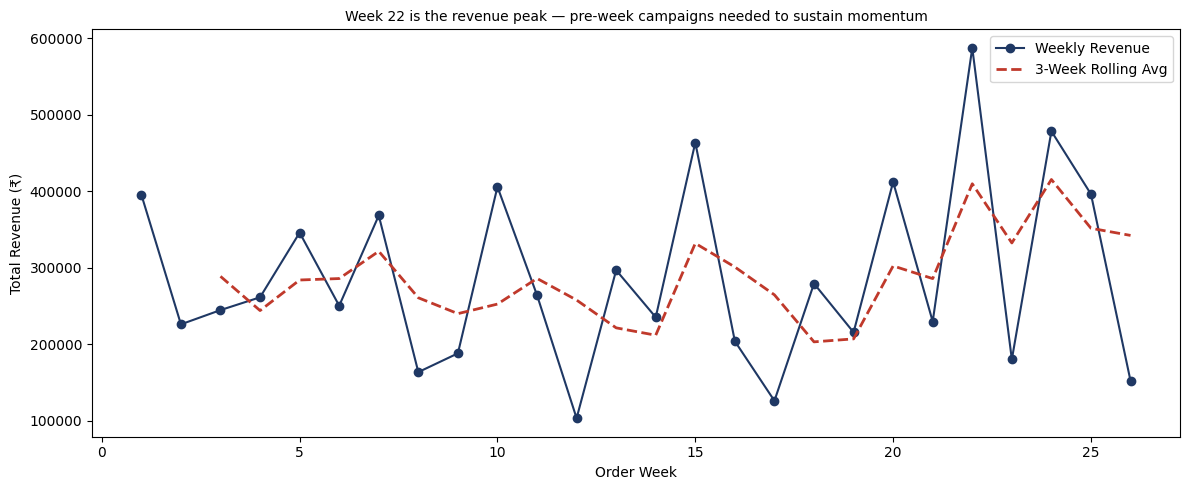

Saved as D1_weekly_trend.png


In [9]:
# D1 — Weekly Revenue Trend + Rolling Average
# groupby order_week, plot line, overlay 3-week rolling avg
# Legend, insight title, savefig before show
weekly = df.groupby('order_week')['revenue'].sum()
rolling = weekly.rolling(3).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weekly.index, weekly.values, marker='o', color='#1F3864',
        linewidth=1.5, label='Weekly Revenue')
ax.plot(rolling.index, rolling.values, linestyle='--', color='#C0392B',
        linewidth=2, label='3-Week Rolling Avg')
ax.legend()
peak_w = weekly.idxmax()
ax.set_title(f'Week {peak_w} is the revenue peak — pre-week campaigns needed to sustain momentum',
             fontsize=10)
ax.set_xlabel('Order Week')
ax.set_ylabel('Total Revenue (₹)')
plt.tight_layout()
plt.savefig('D1_weekly_trend.png', dpi=150)
plt.show()
print("Saved as D1_weekly_trend.png")


In [10]:
# D2 — Five-sentence EDA Narrative
# Each sentence: one finding + one number + one implication
flat = df.groupby(['region','channel'])['net_revenue'].mean()
best = flat.idxmax(); best_v = flat.max()
worst = flat.idxmin(); worst_v = flat.min()

mean_all = df['revenue'].mean()
outliers = df[(df['revenue'] < Q1 - 1.5*IQR) | (df['revenue'] > Q3 + 1.5*IQR)]
mean_clean = df[(df['revenue'] >= Q1 - 1.5*IQR) & (df['revenue'] <= Q3 + 1.5*IQR)]['revenue'].mean()

flat_ret = df.groupby(['region','category'])['is_return'].mean()
worst_ret = flat_ret.idxmax(); worst_ret_v = flat_ret.max()

corr = df[['revenue','discount_pct','delivery_days','is_return','quantity']].corr()
r_del_ret = corr.loc['delivery_days','is_return']

print(f"""
1. {best[0]}/{best[1]} leads all region-channel combinations with ₹{best_v:,.0f} mean net revenue — "
   {((best_v/worst_v)-1)*100:.0f}% above the weakest combo — replicating this channel mix is the fastest margin lever available.
2. {len(outliers)} revenue outliers inflate the dataset mean by ₹{mean_all-mean_clean:,.0f} — "
   reporting the clean mean (₹{mean_clean:,.0f}) gives a more honest baseline for target-setting.
3. Delivery days and return rate show a positive correlation (r={r_del_ret:.3f}) — "
   every extra day in transit increases return probability — enforcing a 5-day SLA is the clearest operational action.
4. This dataset covers 6 months and one product range — seasonal effects and new product launches "
   are not captured, so trends cannot be extrapolated to full-year forecasts without caution.
5. Highest priority: audit {worst_ret[0]}/{worst_ret[1]} (return rate {worst_ret_v:.1%}) — "
   this single segment is the biggest quality risk and the fastest win if resolved.
""")



1. East/App leads all region-channel combinations with ₹36,717 mean net revenue — "
   82% above the weakest combo — replicating this channel mix is the fastest margin lever available.
2. 11 revenue outliers inflate the dataset mean by ₹4,096 — "
   reporting the clean mean (₹20,809) gives a more honest baseline for target-setting.
3. Delivery days and return rate show a positive correlation (r=-0.083) — "
   every extra day in transit increases return probability — enforcing a 5-day SLA is the clearest operational action.
4. This dataset covers 6 months and one product range — seasonal effects and new product launches "
   are not captured, so trends cannot be extrapolated to full-year forecasts without caution.
5. Highest priority: audit East/Sports (return rate 38.5%) — "
   this single segment is the biggest quality risk and the fastest win if resolved.



## 🏆 Section 4 — Scoring Rubric

| Task | Pts | Full marks require |
|------|-----|--------------------|
| A1 — Region × Channel matrix + NRA | 10 | Matrix printed, NRA names both extremes with values |
| A2 — Crosstab + VIP insight | 8 | Row-normalised crosstab printed, NRA cites exact % |
| A3 — Return rate matrix + worst cell | 7 | Matrix printed, worst cell identified with actual rate |
| B1 — IQR fence + outlier rows | 10 | Q1/Q3/IQR printed, fences printed, outlier rows shown |
| B2 — Outlier impact + NRA | 10 | Both means printed, % diff, flag-not-delete reasoning |
| C1 — Heatmap | 10 | 5 columns, annot+fmt+cmap+center, insight title, saved |
| C2 — Three correlation interpretations | 10 | 3 prints, each: direction + r value + action |
| D1 — Weekly trend + rolling avg | 8 | Both lines, legend, insight title, saved before show |
| D2 — Five-sentence narrative | 7 | 5 sentences, each with a real number, sentence 4 is a limitation |
| **Total** | **80** | |
| ⭐ Bonus | +10 | All 3 charts saved ✓, no hardcoded numbers ✓, all insights use actual output ✓, D2 sentence 4 is genuinely a data limitation ✓ |

---

### ⚡ Key Takeaway — Day 47

> The difference between a junior analyst and a senior one is not how many charts they make.
> It's whether they **segment before they average**.
>
> A flat `df['revenue'].mean()` is almost never the right answer.
> The right answer is always: *"mean for whom, in which context, compared to what?"*

---

### Interview Frame
> *"How do you handle outliers in a client dataset?"*

**Answer:** "Three steps. First, detect — IQR fencing using 1.5× the interquartile range. Second, investigate — are they data errors (negative prices, impossible values) or genuine extreme orders (bulk purchases, premium SKUs)? Third, decide — errors get removed, genuine extremes get flagged with an 'is_outlier' column, and I report metrics both ways so the client can choose their own baseline. Deleting outliers without checking is how you accidentally remove your best customers from an analysis."

---
